# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

*Answers - Q1*

1. The intuition of adding an increasing penalty is to discourage models that are too complicated. The model is penalized for using large coefficients, so the penalty forces the model to only keep the ones that improve results while eliminating or shrinking the rest, which ultimately helps prevent overfitting.
2. Regularization allows us to control model complexity which directly ties into bias and variance. For instance, increasing the penalty shrinks coefficients (to create a simpler model) which correlates to higher bias and lower variance, while decreasing the penalty allows larger coefficients which correlates to lower bias, higher variance. So choosing the penalty in regularization directly affects the bias-variance tradeoff.
3. LASSO can zero coefficients out and automatically select a model, while Ridge will shrink all of the coefficients but not exactly to zero. So Ridge will keep all the variables but just make the smaller while LASSO will select a subset of the important variables and remove the rest. Generally speaking, in practice Ridge ends up doing better at prediction, and LASSO provides an interpretable result like linear regression.
4. We typically scale variables using z-score normalization so they all have a mean of 0 and standard deviation of 1. This is done because we need to compare the size of the coefficients but if the variables are on different scales, it can lead to incorrect conclusions due to units, not the actual significance of those variables. So since the variable scales themselves impact the mathematical interpretation of the penalty, it is necessary to scale variables for regularized regression.
5. The penalty is typically selected by cross validation to find a value for $\alpha$ that isn't too large (since that would zero out all the coefficients) but also isn't too small (since that could cause an overly complex model and lead to overfitting).
6. No, you do not include the penalty term in the evaluated MSE during cross validation. This is because the penalty is only included during training to prevent coeficcients from becoming too large, but isn't actually needed as a measure of predictive performance, so $\alpha$ is generally left out during cross validation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [8]:
### 2.1

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv("data/cars_hw.csv")
df.head()

df["Age"] = 2026 - df["Make_Year"]
X = df[["Mileage_Run", "Age"]]

### (a)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

### (b)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [10]:
### 2.2

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_scaled, df["Price"])  

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
for name, coef in zip(feature_names, model.coef_):
    if name == "Mileage_Run Age":
        print(name, coef)   # the sign is negative for the interaction of Mileage_Run and Age

Mileage_Run Age -1671212.356391884


In [11]:
### 2.3

from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, df["Price"])

lasso.alpha_

c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22977693145.59375, tolerance: 12678950599.999998
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 598283108333.2188, tolerance: 12678950599.999998
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 850706967020.7812, tolerance: 12678950599.999998
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\shalm\miniconda3\envs\pysparken

88.58667904100822

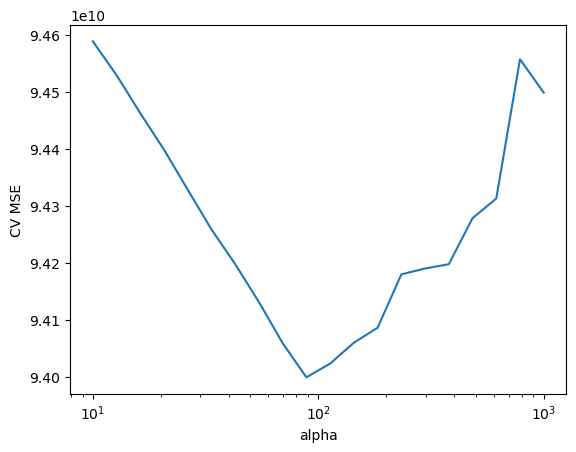

In [12]:
### 2.4
mean_mse = lasso.mse_path_.mean(axis=1)

plt.plot(lasso.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV MSE")
plt.show()

c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.405e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.677e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

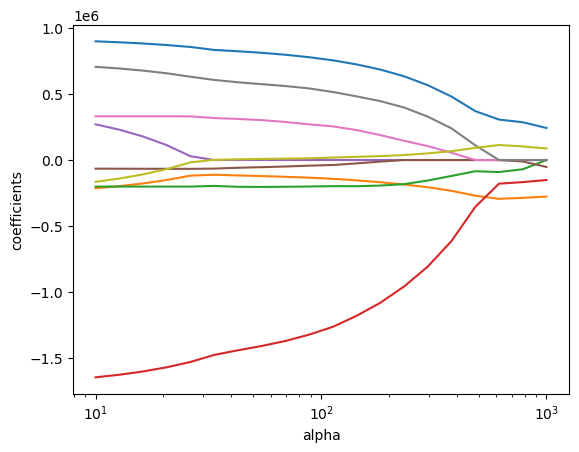

In [13]:
### 2.5

from sklearn.linear_model import Lasso

coefs = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_scaled, df["Price"])
    coefs.append(model.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.show()

In [14]:
### 2.6

# coefficients from best LASSO model
coefs = lasso.coef_

# number of zeros
num_zero = np.sum(coefs == 0)
total = len(coefs)

num_zero, total, num_zero / total  # 1/9 of the coefficients are zero

(1, 9, 0.1111111111111111)

In [15]:
### 2.7

# linear regression coefficients
lin_coefs = model.coef_

# lasso coefficients
lasso_coefs = lasso.coef_

# compare
for name, lin, las in zip(feature_names, lin_coefs, lasso_coefs):
    print(name, " | linear:", lin, " | lasso:", las)

Mileage_Run  | linear: 242953.21638836197  | lasso: 778950.5872674095
Age  | linear: -276500.8957759939  | lasso: -133743.60642026467
Mileage_Run^2  | linear: -0.0  | lasso: -200601.45899564252
Mileage_Run Age  | linear: -151598.5457670135  | lasso: -1323306.5094815446
Age^2  | linear: -0.0  | lasso: 0.0
Mileage_Run^3  | linear: -52410.34753605812  | lasso: -42460.12342085727
Mileage_Run^2 Age  | linear: -0.0  | lasso: 270504.9008226762
Mileage_Run Age^2  | linear: -0.0  | lasso: 542850.4877047453
Age^3  | linear: 87796.74070633299  | lasso: 13341.983986170846


Yes, some coefficients increased in magnitude (like Mileage_Run, Mileage_Run Age, and interaction terms), but no coefficients changed sign between linear regression and LASSO for this data.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [18]:
### 3.1

df = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")
df.head()

# numerical features
X_num = df[["age", "ejection_fraction", "serum_creatinine"]]

poly_num = PolynomialFeatures(degree=3, include_bias=False)
X_num_poly = poly_num.fit_transform(X_num)

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_poly)

# categorical features
X_cat = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

poly_cat = PolynomialFeatures(interaction_only=True, include_bias=False)
X_cat_inter = poly_cat.fit_transform(X_cat)

# concatenate
X = np.concatenate([X_num_scaled, X_cat_inter], axis=1)

In [21]:
### 3.2

y = df["DEATH_EVENT"]

model = LinearRegression()
model.fit(X, y)

num_names = poly_num.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"])
cat_names = poly_cat.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"])
feature_names = np.concatenate([num_names, cat_names])

for name, coef in zip(feature_names, model.coef_):
    print(name + ":", coef)

age: 1.5391556093616545
ejection_fraction: -2.192493664234322
serum_creatinine: -0.8535881544612878
age^2: -3.6786539253257344
age ejection_fraction: -0.6009180269804365
age serum_creatinine: 1.8415625716809925
ejection_fraction^2: 3.4309764645505902
ejection_fraction serum_creatinine: 2.6733936217891308
serum_creatinine^2: -2.6470406100691264
age^3: 1.9931349422978328
age^2 ejection_fraction: 0.9080259541106226
age^2 serum_creatinine: -0.6975215091977047
age ejection_fraction^2: -0.0812063244537519
age ejection_fraction serum_creatinine: -1.5776652636623698
age serum_creatinine^2: 1.2840992885586107
ejection_fraction^3: -1.2503410525099259
ejection_fraction^2 serum_creatinine: -1.2700431389642288
ejection_fraction serum_creatinine^2: 1.1794749306635584
serum_creatinine^3: 0.0721557771730381
anaemia: 0.008092533136947251
diabetes: -0.07070509612689603
high_blood_pressure: -0.007934365189075284
smoking: -0.10268659174928846
anaemia diabetes: 0.026159483759130787
anaemia high_blood_press

Yes, there are counterintuitive sign patterns; for instance, the coefficient for diabetes is negative even though diabetes is typically associated with higher risk of death. This occurs because the model includes many higher-order and interaction terms, so the effect of these variables is distributed across multiple coefficients rather than explained by the linear term alone. For example, all the diabetes interaction terms have a positive coefficient.

In [22]:
### 3.3
from sklearn.linear_model import LassoCV

alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X, y)

# best alpha
lasso.alpha_

c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.1655699255992573, tolerance: 0.005832394366197183
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.0194224382742867, tolerance: 0.005832394366197183
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.95487046016755, tolerance: 0.005832394366197183
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\shalm\miniconda3\envs\py

0.005736152510448681

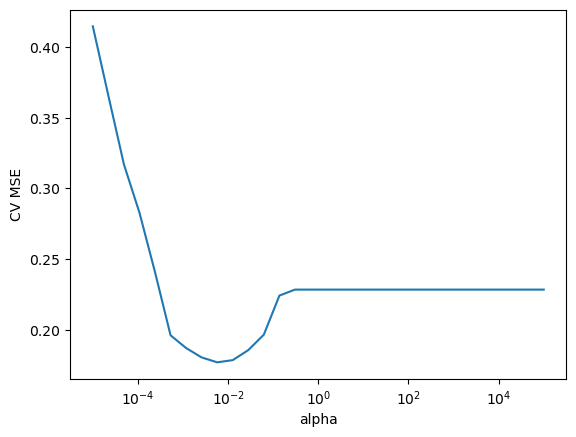

In [24]:
### 3.4

mean_mse = lasso.mse_path_.mean(axis=1)

plt.plot(lasso.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV MSE")
plt.show()


c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.908e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.666e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

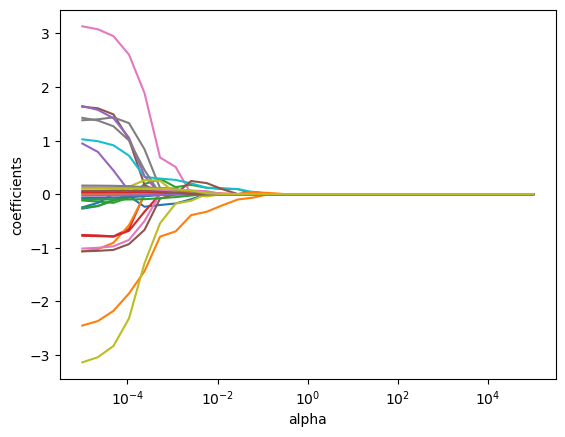

In [25]:
### 3.5

from sklearn.linear_model import Lasso

coefs = []

for a in alphas:
    m = Lasso(alpha=a, max_iter=10000)
    m.fit(X, y)
    coefs.append(m.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.show()

In [27]:
### 3.6
num_names = poly_num.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"])
cat_names = poly_cat.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"])
feature_names = np.concatenate([num_names, cat_names])

lin_coefs = model.coef_
lasso_coefs = lasso.coef_

results = pd.DataFrame({
    "feature": feature_names,
    "linear": lin_coefs,
    "lasso": lasso_coefs
})

# selected features
selected = results[results["lasso"] != 0]
print("Selected features:")
print(selected[["feature", "lasso"]])

# proportion set to zero
prop_zero = np.mean(results["lasso"] == 0)
print("\nProportion set to zero:")
print(prop_zero)

print("\nFull comparison:")
print(results)

Selected features:
                                 feature     lasso
1                      ejection_fraction -0.329656
2                       serum_creatinine  0.116875
9                                  age^3  0.117992
15                   ejection_fraction^3  0.204822
16  ejection_fraction^2 serum_creatinine  0.032801
18                    serum_creatinine^3 -0.043266
19                               anaemia  0.014178
20                              diabetes  0.000607
21                   high_blood_pressure  0.013608
26          diabetes high_blood_pressure  0.053968
27                      diabetes smoking  0.003466
28           high_blood_pressure smoking  0.017805

Proportion set to zero:
0.5862068965517241

Full comparison:
                                   feature    linear     lasso
0                                      age  1.539156 -0.000000
1                        ejection_fraction -2.192494 -0.329656
2                         serum_creatinine -0.853588  0.116875
3   

A few coefficients increase slightly in magnitude (anaemia and high_blood_pressure), but most are shrunk or set to zero. Yes, several coefficients change sign, including serum_creatinine and diabetes, and many of the higher order terms either flip signs or go to zero. I think LASSO makes more sense; for instance, diabetes typically indicates an increased risk of death so we would expect a positive coefficient which LASSO has but linear regression doesn't, and just in general, LASSO removes a lot of higher-order and unecessary terms from the model. From the perspective of bias-variance tradeoff, linear regression has low bias but high variance, leading to unstable and sometimes counterintuitive coefficients, while LASSO introduces slightly higher bias but reduces variance, producing more stable and interpretable results.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

#### 4.1
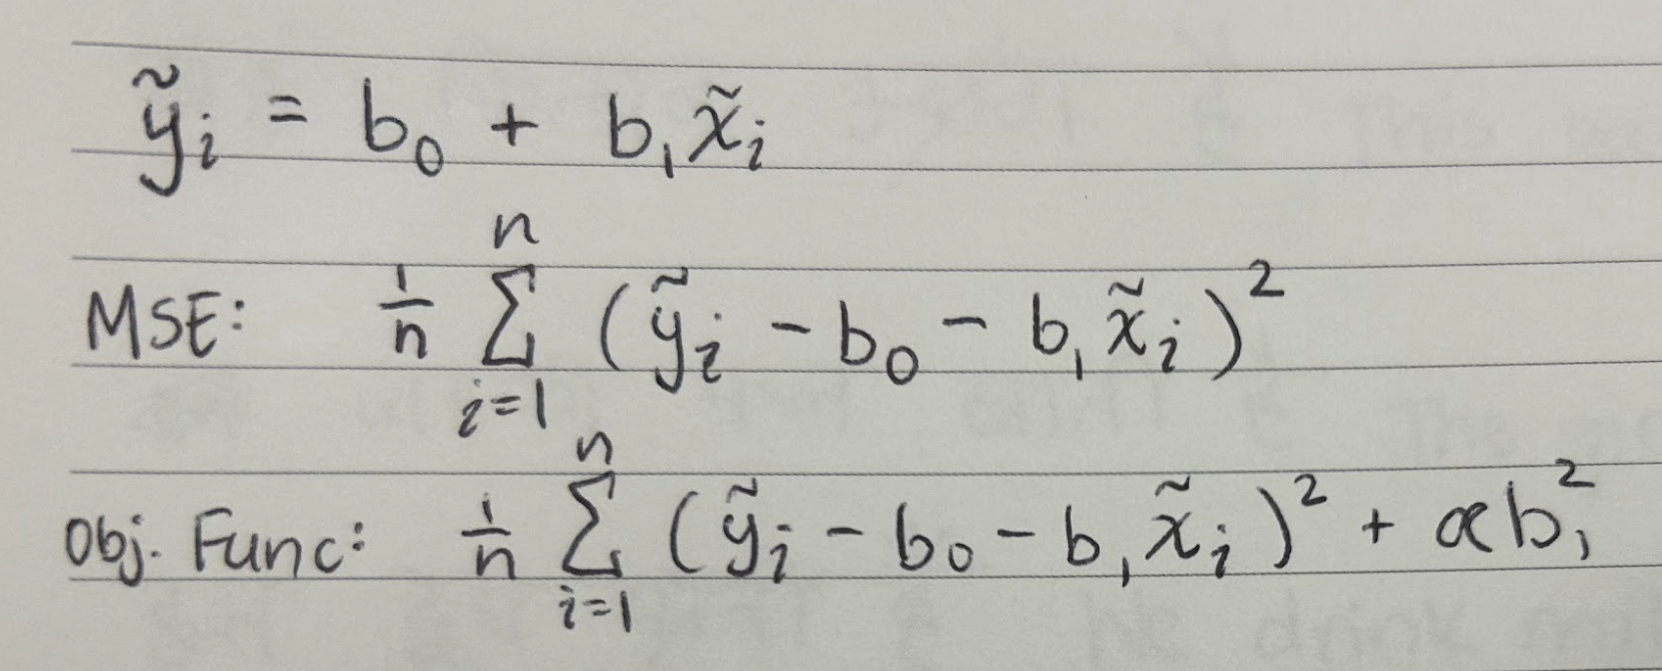

#### 4.2
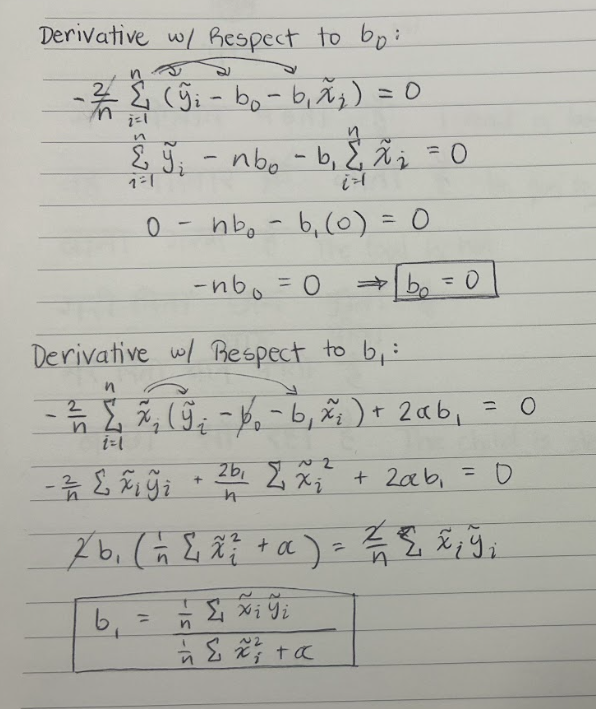

#### 4.3
Since $\alpha$ is in the denominator of the slope $b_1$ (from the result of 4.2), increasing $\alpha$ will increase the denominator which ultimately decreases the slope.

#### 4.4
The challenge with using the LASSO penalty is that $|b_1|$ is not differentiable at 0, so we have to consider cases instead ($b_1 > 0$, $b_1 < 0$, and $b_1 = 0$). It is optimal to set $b_1 = 0$ when the relationship between $\tilde{y}_i$ and $\tilde{x}_i$ is too weak to overcome the penalty, as this is how LASSO does feature selction.